In [176]:
from sqlalchemy import create_engine, text
from datetime import datetime, timedelta
import pandas as pd
import os
import shutil
import tempfile
from pathlib import Path

def _get_distillates_engine():
    user = os.getenv("DISTILLATES_USER", "BBallard")
    password = os.getenv("DISTILLATES_PASS", "927345bggo23h49thojwnr")
    host = os.getenv("DISTILLATES_HOST", "mosaic-fundamental-odbc.mosaic.hartreepartners.com")
    port = os.getenv("DISTILLATES_PORT", "3306")
    connection_url = f"mysql+pymysql://{user}:{password}@{host}:{port}/"
    return create_engine(connection_url, future=True)

def read_excel_safe(path, **kwargs):
    """Copy file to temp, read, delete temp - prevents file locking."""
    tmp = tempfile.NamedTemporaryFile(delete=False, suffix=Path(path).suffix)
    tmp.close()
    shutil.copy2(path, tmp.name)
    df = pd.read_excel(tmp.name, **kwargs)
    Path(tmp.name).unlink()
    return df

PORT_MAPPING_FILE = r"C:\Users\bballard.HETCO\ShipTracking Email\W Europe Balance Main Ben.xlsb"

def load_port_mapping():
    """Load port mapping from the new Excel file.
    Returns a DataFrame with BerthName -> TradeZone2_Dist (trading region) and Region2_Dist (continent).
    """
    df = read_excel_safe(PORT_MAPPING_FILE, sheet_name='PortFileServer', engine='pyxlsb')
    df['BerthName'] = df['BerthName'].astype(str).str.upper().str.strip()
    df['TransalatedName'] = df['TransalatedName'].astype(str).str.upper().str.strip()
    df['TradeZone2_Dist'] = df['TradeZone2_Dist'].astype(str).str.upper().str.strip()
    df['Region2_Dist'] = df['Region2_Dist'].astype(str).str.upper().str.strip()
    return df

def load_ht_data(start_days_offset=3,
                 grade_translation_file=r"S:\Raaina\Shiptracking\GradeTransalation.xlsx"):
    """Load ship tracking data from database and apply grade filtering.
    Loads all statuses: ON WAY TO DEST, ON SUBS, FIXED, DISCHARGED
    """
    engine = _get_distillates_engine()

    sql_n = """
        SELECT movement_id,
               vessel_name,
               vessel_imo,
               grade,
               quantity,
               charterer,
               load,
               load_region,
               destination_start,
               load_end,
               destination,
               destination_region,
               destination_end,
               status,
               comment,
               buyer,
               update_timestamp
        FROM distillates_ship_tracking.movements
        WHERE status IN ('ON WAY TO DEST', 'ON SUBS', 'FIXED', 'DISCHARGED')
    """

    with engine.connect() as conn:
        hrtr_l0 = pd.read_sql_query(text(sql_n), conn)

    grade_file = pd.read_excel(grade_translation_file)
    grade_file = grade_file.apply(lambda x: x.astype(str).str.upper())
    hrtr_l0['grade'] = hrtr_l0['grade'].str.upper()
    hrtr_l0 = hrtr_l0.merge(grade_file, left_on='grade', right_on='Grade', how='left')
    hrtr_l0 = hrtr_l0[hrtr_l0.Grade1.isin(['HS', '10-50ppm', '10-50PPM'])]

    # Apply port mapping for trading regions and continents
    port_map = load_port_mapping()
    
    # Map load port to trading region and continent
    hrtr_l0['load'] = hrtr_l0['load'].astype(str).str.upper().str.strip()
    load_map = port_map[['BerthName', 'TradeZone2_Dist', 'Region2_Dist']].drop_duplicates('BerthName')
    hrtr_l0 = hrtr_l0.merge(load_map, left_on='load', right_on='BerthName', how='left')
    hrtr_l0 = hrtr_l0.rename(columns={'TradeZone2_Dist': 'load_trading_region', 'Region2_Dist': 'load_continent'})
    hrtr_l0 = hrtr_l0.drop(columns=['BerthName'])
    
    # Map destination port to trading region and continent
    hrtr_l0['destination'] = hrtr_l0['destination'].astype(str).str.upper().str.strip()
    dest_map = port_map[['BerthName', 'TradeZone2_Dist', 'Region2_Dist']].drop_duplicates('BerthName')
    hrtr_l0 = hrtr_l0.merge(dest_map, left_on='destination', right_on='BerthName', how='left', suffixes=('', '_dest'))
    hrtr_l0 = hrtr_l0.rename(columns={'TradeZone2_Dist': 'destination_trading_region', 'Region2_Dist': 'destination_continent'})
    hrtr_l0 = hrtr_l0.drop(columns=['BerthName'])

    hrtr_l0['load_end'] = pd.to_datetime(hrtr_l0['load_end'], errors='coerce')
    hrtr_l0['destination_end'] = pd.to_datetime(hrtr_l0['destination_end'], errors='coerce')
    hrtr_l0 = hrtr_l0.sort_values('load_end')

    return hrtr_l0

In [151]:
one_year_cutoff = pd.Timestamp(datetime.today()) - pd.DateOffset(years=1)

# Load data and filter to ON WAY TO DEST (oil on water)
OOW_df = load_ht_data().copy()
OOW_df['load_end'] = pd.to_datetime(OOW_df['load_end'], errors='coerce')
OOW_df = OOW_df[
    (OOW_df['load_end'] >= one_year_cutoff) &
    (OOW_df['status'] == 'ON WAY TO DEST')
].copy()

print(f"Cutoff date (today - 1 year): {one_year_cutoff.date()}")
print(f"Loaded {len(OOW_df)} vessels on water (ON WAY TO DEST)")

Cutoff date (today - 1 year): 2025-03-11
Loaded 266 vessels on water (ON WAY TO DEST)


In [152]:
import pandas as pd
from IPython.display import display

# Filter to ON WAY TO DEST for fleet status (oil on water)
fleet_df = OOW_df[OOW_df['status'] == 'ON WAY TO DEST'].copy()

fleet_df['quantity'] = pd.to_numeric(fleet_df['quantity'], errors='coerce').fillna(0.0)
fleet_df['load_trading_region'] = fleet_df['load_trading_region'].astype(str).str.upper().str.strip()
fleet_df['destination_trading_region'] = fleet_df['destination_trading_region'].astype(str).str.upper().str.strip()
fleet_df['load_continent'] = fleet_df['load_continent'].astype(str).str.upper().str.strip()
fleet_df['destination_continent'] = fleet_df['destination_continent'].astype(str).str.upper().str.strip()

# Constants for filtering (based on Region2_Dist and TradeZone2_Dist values)
EOS_CONTINENT = 'AG+RSEA+INDIA'
RUSSIAN_CONTINENT = 'FSU'
EUROPE_CONTINENT = 'EUROPE'
EAST_CONTINENT = 'EAST'
PADD1_DESTINATION_TRADING_REGION = 'USAC'
US_TRADING_REGIONS = ['USAC', 'USGC', 'USWC', 'US PADD 2']

us_to_europe_df = fleet_df[
    (fleet_df['load_trading_region'].isin(US_TRADING_REGIONS))
    & (fleet_df['destination_continent'] == EUROPE_CONTINENT)
].copy()

eos_to_europe_df = fleet_df[
    (fleet_df['load_continent'] == EOS_CONTINENT)
    & (fleet_df['destination_continent'] == EUROPE_CONTINENT)
].copy()

eos_to_east_df = fleet_df[
    (fleet_df['load_continent'] == EOS_CONTINENT)
    & (fleet_df['destination_continent'] == EAST_CONTINENT)
].copy()

all_to_padd1_df = fleet_df[
    fleet_df['destination_trading_region'] == PADD1_DESTINATION_TRADING_REGION
].copy()

russia_to_all_df = fleet_df[
    fleet_df['load_continent'] == RUSSIAN_CONTINENT
].copy()

fleet_status_summary = pd.DataFrame({
    'fleet_status': [
        'US to Europe',
        'EoS to Europe',
        'EoS to EAST',
        'All to PADD1',
        'RUSSIA to All'
    ],
    'vessel_records': [
        len(us_to_europe_df),
        len(eos_to_europe_df),
        len(eos_to_east_df),
        len(all_to_padd1_df),
        len(russia_to_all_df)
    ],
    'cumulative_quantity_kt_raw': [
        us_to_europe_df['quantity'].sum(),
        eos_to_europe_df['quantity'].sum(),
        eos_to_east_df['quantity'].sum(),
        all_to_padd1_df['quantity'].sum(),
        russia_to_all_df['quantity'].sum()
    ]
})
fleet_status_summary['cumulative_quantity_kt'] = fleet_status_summary['cumulative_quantity_kt_raw'].round(-1).astype(int)

print(f"Fleet Status Summary (ON WAY TO DEST only - oil on water)")
print(f"Total vessels on water: {len(fleet_df)}")
display(fleet_status_summary[['fleet_status', 'vessel_records', 'cumulative_quantity_kt']])

Fleet Status Summary (ON WAY TO DEST only - oil on water)
Total vessels on water: 266


,fleet_status,vessel_records,cumulative_quantity_kt
0,US to Europe,24,970
1,EoS to Europe,28,2200
2,EoS to EAST,9,820
3,All to PADD1,5,100
4,RUSSIA to All,74,2810


In [153]:
from pathlib import Path
from IPython.display import display

snapshot_dir = Path('snapshots')
snapshot_dir.mkdir(parents=True, exist_ok=True)

base_cols = [
    'movement_id', 'vessel_name', 'vessel_imo', 'charterer', 'quantity',
    'load', 'load_trading_region', 'load_continent', 'load_end',
    'destination', 'destination_trading_region', 'destination_continent', 'destination_end',
    'status', 'comment'
]

# US trading regions for filtering
US_TRADING_REGIONS = ['USAC', 'USGC', 'USWC', 'US PADD 2']

# Filter to ON WAY TO DEST for snapshot tracking (oil on water)
flow_df = OOW_df[OOW_df['status'] == 'ON WAY TO DEST'].copy()
for col in base_cols:
    if col not in flow_df.columns:
        flow_df[col] = pd.NA

flow_df['quantity'] = pd.to_numeric(flow_df['quantity'], errors='coerce').fillna(0.0)
flow_df['load_trading_region'] = flow_df['load_trading_region'].astype(str).str.upper().str.strip()
flow_df['destination_trading_region'] = flow_df['destination_trading_region'].astype(str).str.upper().str.strip()
flow_df['load_continent'] = flow_df['load_continent'].astype(str).str.upper().str.strip()
flow_df['destination_continent'] = flow_df['destination_continent'].astype(str).str.upper().str.strip()


def round_to_10(value):
    return int(pd.Series([value]).round(-1).iloc[0])


def prep_snapshot(df):
    snap = df[base_cols].copy()
    snap['quantity'] = pd.to_numeric(snap['quantity'], errors='coerce').fillna(0.0)
    snap['load_end'] = pd.to_datetime(snap['load_end'], errors='coerce')
    snap['destination_end'] = pd.to_datetime(snap['destination_end'], errors='coerce')
    snap['snapshot_date'] = pd.Timestamp(datetime.today()).normalize()
    return snap


def read_previous(path):
    if not path.exists():
        return None
    prev = pd.read_csv(path)
    for col in base_cols + ['snapshot_date']:
        if col not in prev.columns:
            prev[col] = pd.NA
    prev['quantity'] = pd.to_numeric(prev['quantity'], errors='coerce').fillna(0.0)
    prev['load_end'] = pd.to_datetime(prev['load_end'], errors='coerce')
    prev['destination_end'] = pd.to_datetime(prev['destination_end'], errors='coerce')
    return prev


def format_added_table(df):
    return df[[
        'vessel_name', 'charterer', 'quantity', 'load_end', 'destination', 'destination_end', 'status'
    ]].rename(columns={
        'vessel_name': 'Vessel Name',
        'charterer': 'Charterer',
        'quantity': 'Quantity',
        'load_end': 'ETS',
        'destination': 'Destination',
        'destination_end': 'ETA',
        'status': 'Status'
    })


def format_removed_table(df):
    table = df[[
        'vessel_name', 'charterer', 'quantity', 'load', 'load_end'
    ]].rename(columns={
        'vessel_name': 'Vessel Name',
        'charterer': 'Charterer',
        'quantity': 'Quantity',
        'load': 'Origin',
        'load_end': 'ETS'
    })
    table['Removed Because'] = ''
    table['Removed From'] = ''
    table['Comment'] = ''
    return table


def format_changed_table(curr_snap, prev_snap):
    curr_ids = set(curr_snap['vessel_imo'].astype(str))
    prev_ids = set(prev_snap['vessel_imo'].astype(str))
    common_ids = curr_ids & prev_ids

    curr_common = curr_snap[curr_snap['vessel_imo'].astype(str).isin(common_ids)].copy()
    prev_common = prev_snap[prev_snap['vessel_imo'].astype(str).isin(common_ids)].copy()

    curr_common = curr_common.set_index(curr_common['vessel_imo'].astype(str))
    prev_common = prev_common.set_index(prev_common['vessel_imo'].astype(str))

    joined = prev_common[['vessel_name', 'charterer', 'quantity', 'load_end', 'destination', 'destination_end', 'status']].join(
        curr_common[['destination', 'destination_end', 'status']],
        how='inner',
        lsuffix='_yday',
        rsuffix='_today'
    )

    changed = joined[
        joined['destination_yday'].fillna('').astype(str).str.upper().str.strip()
        != joined['destination_today'].fillna('').astype(str).str.upper().str.strip()
    ].copy()

    return changed.reset_index()[[
        'vessel_name', 'charterer', 'quantity', 'load_end',
        'destination_yday', 'destination_today',
        'destination_end_yday', 'destination_end_today',
        'status_today'
    ]].rename(columns={
        'vessel_name': 'Vessel Name',
        'charterer': 'Charterer',
        'quantity': 'Quantity',
        'load_end': 'ETS',
        'destination_yday': 'Destination (Yesterday)',
        'destination_today': 'Destination (Today)',
        'destination_end_yday': 'ETA (Yesterday)',
        'destination_end_today': 'ETA (Today)',
        'status_today': 'Status'
    })


def run_flow(title, flow_label, curr_snap, snapshot_file, second_table_type):
    prev_snap = read_previous(snapshot_file)
    today_kt = curr_snap['quantity'].sum()

    print(f'{title} - Daily Change Summary')
    if prev_snap is None:
        print(f'No previous {title.lower()} snapshot found. Saved today as baseline.')
        print(f"Current {flow_label.lower()} kt: {round_to_10(today_kt)}")

        empty_added = pd.DataFrame(columns=['Vessel Name', 'Charterer', 'Quantity', 'ETS', 'Destination', 'ETA', 'Status'])
        if second_table_type == 'removed':
            empty_second = pd.DataFrame(columns=['Vessel Name', 'Charterer', 'Quantity', 'Origin', 'ETS', 'Removed Because', 'Removed From', 'Comment'])
            second_title = 'Vessels Removed'
        else:
            empty_second = pd.DataFrame(columns=['Vessel Name', 'Charterer', 'Quantity', 'ETS', 'Destination (Yesterday)', 'Destination (Today)', 'ETA (Yesterday)', 'ETA (Today)', 'Status'])
            second_title = 'Vessels Changed (Diversions)'

        print(f'\n{title} - Vessels Added')
        display(empty_added)
        print(f'\n{title} - {second_title}')
        display(empty_second)
    else:
        yday_kt = prev_snap['quantity'].sum()
        delta_kt = today_kt - yday_kt

        curr_ids = set(curr_snap['vessel_imo'].astype(str))
        prev_ids = set(prev_snap['vessel_imo'].astype(str))
        added_df = curr_snap[curr_snap['vessel_imo'].astype(str).isin(curr_ids - prev_ids)].copy()

        if second_table_type == 'removed':
            second_df = prev_snap[prev_snap['vessel_imo'].astype(str).isin(prev_ids - curr_ids)].copy()
            second_table = format_removed_table(second_df)
            second_metric_name = 'Vessels removed'
            second_title = 'Vessels Removed'
            second_count = len(second_df)
        else:
            second_table = format_changed_table(curr_snap, prev_snap)
            second_metric_name = 'Vessels changed (diversions)'
            second_title = 'Vessels Changed (Diversions)'
            second_count = len(second_table)

        added_table = format_added_table(added_df)

        summary_df = pd.DataFrame([
            {'metric': f'{flow_label} kt (today)', 'value': round_to_10(today_kt)},
            {'metric': f'{flow_label} kt (yesterday)', 'value': round_to_10(yday_kt)},
            {'metric': f'{flow_label} change kt (today - yesterday)', 'value': round_to_10(delta_kt)},
            {'metric': 'Vessels added', 'value': len(added_df)},
            {'metric': second_metric_name, 'value': second_count}
        ])

        display(summary_df)
        print(f'\n{title} - Vessels Added')
        display(added_table.sort_values('Quantity', ascending=False))
        print(f'\n{title} - {second_title}')
        display(second_table.sort_values('Quantity', ascending=False))

    curr_snap.to_csv(snapshot_file, index=False)
    print(f'{title} snapshot saved: {snapshot_file}')
    print('')


run_flow(
    title='Europe Imports',
    flow_label='Imports',
    curr_snap=prep_snapshot(flow_df[flow_df['destination_continent'] == 'EUROPE']),
    snapshot_file=snapshot_dir / 'europe_imports_latest.csv',
    second_table_type='removed'
)

run_flow(
    title='ARA Imports',
    flow_label='Imports',
    curr_snap=prep_snapshot(flow_df[flow_df['destination_trading_region'] == 'ARA']),
    snapshot_file=snapshot_dir / 'ara_imports_latest.csv',
    second_table_type='removed'
)

run_flow(
    title='ARA Exports',
    flow_label='Exports',
    curr_snap=prep_snapshot(flow_df[flow_df['load_trading_region'] == 'ARA']),
    snapshot_file=snapshot_dir / 'ara_exports_latest.csv',
    second_table_type='changed'
)

run_flow(
    title='US Exports',
    flow_label='Exports',
    curr_snap=prep_snapshot(flow_df[flow_df['load_trading_region'].isin(US_TRADING_REGIONS)]),
    snapshot_file=snapshot_dir / 'us_exports_latest.csv',
    second_table_type='changed'
)

Europe Imports - Daily Change Summary


,metric,value
0,Imports kt (today),4080
1,Imports kt (yesterday),4080
2,Imports change kt (today - yesterday),0
3,Vessels added,0
4,Vessels removed,0



Europe Imports - Vessels Added


,Vessel Name,Charterer,Quantity,ETS,Destination,ETA,Status



Europe Imports - Vessels Removed


...


US Exports - Vessels Added


,Vessel Name,Charterer,Quantity,ETS,Destination,ETA,Status



US Exports - Vessels Changed (Diversions)


,Vessel Name,Charterer,Quantity,ETS,Destination (Yesterday),Destination (Today),ETA (Yesterday),ETA (Today),Status


US Exports snapshot saved: snapshots\us_exports_latest.csv



In [154]:
import warnings
import calendar
warnings.filterwarnings('ignore')

current_month = pd.Timestamp.today().to_period('M')
# Get 4 months forward: M, M+1, M+2, M+3
months_to_pull = [current_month + i for i in range(4)]

def kbd_to_kt(kbd_value, month_period):
    """Convert KBD (thousand barrels per day) to KT (kilotons).
    Formula: KT = KBD * days_in_month / 7.45
    """
    if kbd_value is None or pd.isna(kbd_value):
        return None
    # Get days in month from period
    year = month_period.year
    month = month_period.month
    days_in_month = calendar.monthrange(year, month)[1]
    return round(kbd_value * days_in_month / 7.45)

# Europe Balance (W Europe Balance Main.xlsb, Imports sheet)
# col A=date, AP=total, AR=US+Canada, AS=AG+RSEA+INDIA, AU=FSU
eu_df = read_excel_safe(r"S:\EuroDist\Analysis\Balances\W Europe Balance Main.xlsb",
                        sheet_name='Imports', header=None, usecols='A,AP,AR,AS,AU', engine='pyxlsb')
eu_df.columns = ['date_raw', 'total', 'us_canada', 'ag_rsea_india', 'fsu']
eu_df['date'] = pd.to_datetime(pd.to_numeric(eu_df['date_raw'], errors='coerce'), unit='D', origin='1899-12-30', errors='coerce')
for col in ['total', 'us_canada', 'ag_rsea_india', 'fsu']:
    eu_df[col] = pd.to_numeric(eu_df[col], errors='coerce')
eu_df = eu_df.dropna(subset=['date'])
eu_df['month'] = eu_df['date'].dt.to_period('M')

europe_assumptions = {}
for month in months_to_pull:
    month_data = eu_df[eu_df['month'] == month]
    if len(month_data) > 0:
        row = month_data.iloc[0]
        europe_assumptions[str(month)] = {
            'total': kbd_to_kt(row['total'], month),
            'us_canada': kbd_to_kt(row['us_canada'], month),
            'ag_rsea_india': kbd_to_kt(row['ag_rsea_india'], month),
            'fsu': kbd_to_kt(row['fsu'], month)
        }

# US Balance (US Balance.xlsm, Exports sheet)
# col B=date, H=PADD3, K=Europe, L=LatAm
us_df = read_excel_safe(r"S:\EuroDist\Analysis\Balances\US Balance.xlsm",
                        sheet_name='Exports', header=None, usecols='B,H,K,L', engine='openpyxl')
us_df.columns = ['date_raw', 'padd3', 'europe', 'latam']
us_df['date'] = pd.to_datetime(us_df['date_raw'], errors='coerce')
for col in ['padd3', 'europe', 'latam']:
    us_df[col] = pd.to_numeric(us_df[col], errors='coerce')
us_df = us_df.dropna(subset=['date'])
us_df['month'] = us_df['date'].dt.to_period('M')

us_assumptions = {}
for month in months_to_pull:
    month_data = us_df[us_df['month'] == month]
    if len(month_data) > 0:
        row = month_data.iloc[0]
        us_assumptions[str(month)] = {
            'padd3': kbd_to_kt(row['padd3'], month),
            'europe': kbd_to_kt(row['europe'], month),
            'latam': kbd_to_kt(row['latam'], month)
        }

# Russian Balance (Russian Balance.xlsm, Russia SnD sheet)
# col A=date, BK=Turkey, BO=LatAm, CO=Total exports
ru_df = read_excel_safe(r"S:\EuroDist\Analysis\Balances\Russian Balance.xlsm",
                        sheet_name='Russia SnD', header=None, usecols='A,BK,BO,CO', engine='openpyxl')
ru_df.columns = ['date_raw', 'turkey', 'latam', 'total']
ru_df['date'] = pd.to_datetime(ru_df['date_raw'], errors='coerce')
for col in ['turkey', 'latam', 'total']:
    ru_df[col] = pd.to_numeric(ru_df[col], errors='coerce')
ru_df = ru_df.dropna(subset=['date'])
ru_df['month'] = ru_df['date'].dt.to_period('M')

russia_assumptions = {}
for month in months_to_pull:
    month_data = ru_df[ru_df['month'] == month]
    if len(month_data) > 0:
        row = month_data.iloc[0]
        russia_assumptions[str(month)] = {
            'total': kbd_to_kt(row['total'], month),
            'turkey': kbd_to_kt(row['turkey'], month),
            'latam': kbd_to_kt(row['latam'], month)
        }

# Display results
print("=" * 60)
print(f"BALANCE ASSUMPTIONS (4 months forward from {current_month})")
print("Units converted from KBD to KT: KT = KBD × days_in_month ÷ 7.45")
print("=" * 60)

print("\nEurope Imports (KT):")
for month in months_to_pull:
    m = str(month)
    days = calendar.monthrange(month.year, month.month)[1]
    if m in europe_assumptions:
        a = europe_assumptions[m]
        print(f"  {m} ({days} days): Total={a['total']}, US+Canada={a['us_canada']}, AG+RSEA+INDIA={a['ag_rsea_india']}, FSU={a['fsu']}")

print("\nUS Exports (KT):")
for month in months_to_pull:
    m = str(month)
    days = calendar.monthrange(month.year, month.month)[1]
    if m in us_assumptions:
        a = us_assumptions[m]
        print(f"  {m} ({days} days): PADD3={a['padd3']}, Europe={a['europe']}, LatAm={a['latam']}")

print("\nRussia Exports (KT):")
for month in months_to_pull:
    m = str(month)
    days = calendar.monthrange(month.year, month.month)[1]
    if m in russia_assumptions:
        a = russia_assumptions[m]
        print(f"  {m} ({days} days): Total={a['total']}, Turkey={a['turkey']}, LatAm={a['latam']}")

BALANCE ASSUMPTIONS (4 months forward from 2026-03)
Units converted from KBD to KT: KT = KBD × days_in_month ÷ 7.45

Europe Imports (KT):
  2026-03 (31 days): Total=4885, US+Canada=1232, AG+RSEA+INDIA=2530, FSU=1082
  2026-04 (30 days): Total=4190, US+Canada=727, AG+RSEA+INDIA=2416, FSU=1007
  2026-05 (31 days): Total=4027, US+Canada=660, AG+RSEA+INDIA=2284, FSU=1041
  2026-06 (30 days): Total=4142, US+Canada=765, AG+RSEA+INDIA=2150, FSU=1146

US Exports (KT):
  2026-03 (31 days): PADD3=4444, Europe=978, LatAm=3279
  2026-04 (30 days): PADD3=4208, Europe=604, LatAm=3423
  2026-05 (31 days): PADD3=4785, Europe=791, LatAm=3766
  2026-06 (30 days): PADD3=4889, Europe=705, LatAm=3902

Russia Exports (KT):
  2026-03 (31 days): Total=13329, Turkey=6567, LatAm=2268
  2026-04 (30 days): Total=11643, Turkey=6086, LatAm=1973
  2026-05 (31 days): Total=12189, Turkey=6030, LatAm=1872
  2026-06 (30 days): Total=11152, Turkey=5233, LatAm=1832


RAW QUERY: 700 vessels, 27,550 kt (before any mapping)
Destination mapping: 700 mapped, 0 unmapped
Load mapping: 700 mapped, 0 unmapped

Destination EUROPE: 146 vessels, 6,378 kt
Europe-to-Europe (EXCLUDED): 50 vessels, 1,470 kt
  Excluded routes: [['ARA' 'HAMBURG']
 ['EUROTANK AMSTERDAM' 'LAVERA']
 ['ARA' 'DUBLIN']
 ['IMMINGHAM' 'ARA']
 ['ARA' 'MED (EUR)']]
EUROPE IMPORTS (excl. intra-Europe): 96 vessels, 4,908 kt


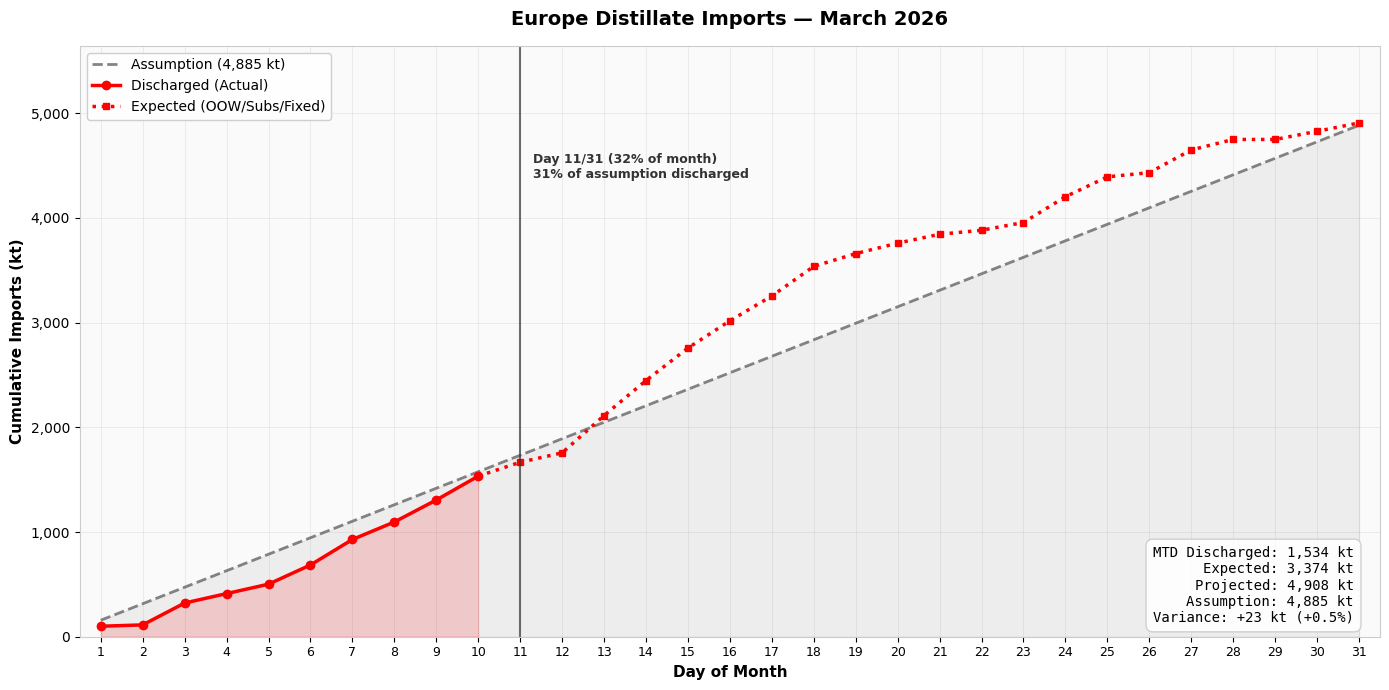

Europe Imports March 2026: 1,534 kt discharged + 3,374 kt expected = 4,908 kt total | vs 4,885 kt assumption (+23 kt / +0.5%)


In [155]:
import matplotlib.pyplot as plt
import calendar

# === SETUP ===
today = pd.Timestamp.today().normalize()
month_start = today.replace(day=1)
month_end = today.replace(day=calendar.monthrange(today.year, today.month)[1])
days_in_month = month_end.day
current_day = today.day
month_name = today.strftime('%B %Y')
month_str = str(today.to_period('M'))

# === QUERY: Current month Europe arrivals ===
engine = _get_distillates_engine()
sql = f"""
    SELECT vessel_name, quantity, grade, load, destination, destination_end, status
    FROM distillates_ship_tracking.movements
    WHERE status IN ('ON WAY TO DEST', 'DISCHARGED', 'ON SUBS', 'FIXED')
      AND destination_end >= '{month_start.strftime('%Y-%m-%d')}'
      AND destination_end <= '{month_end.strftime('%Y-%m-%d')}'
"""
with engine.connect() as conn:
    df_raw = pd.read_sql_query(text(sql), conn)

print(f"RAW QUERY: {len(df_raw)} vessels, {df_raw['quantity'].astype(float).sum():,.0f} kt (before grade filter)")

# Apply grade filter (same as load_ht_data)
grade_file = pd.read_excel(r"S:\Raaina\Shiptracking\GradeTransalation.xlsx")
grade_file = grade_file.apply(lambda x: x.astype(str).str.upper())
df_raw['grade'] = df_raw['grade'].astype(str).str.upper()
df_raw = df_raw.merge(grade_file, left_on='grade', right_on='Grade', how='left')
df_raw = df_raw[df_raw['Grade1'].isin(['HS', '10-50PPM'])]

print(f"After grade filter (HS, 10-50ppm): {len(df_raw)} vessels, {df_raw['quantity'].astype(float).sum():,.0f} kt")

# Load port mapping
port_map = load_port_mapping()
port_lookup = port_map[['BerthName', 'Region2_Dist']].drop_duplicates('BerthName')

# Normalize port names
df_raw['destination'] = df_raw['destination'].astype(str).str.upper().str.strip()
df_raw['load'] = df_raw['load'].astype(str).str.upper().str.strip()

# Map DESTINATION to continent
df = df_raw.merge(port_lookup, left_on='destination', right_on='BerthName', how='left')
df = df.rename(columns={'Region2_Dist': 'dest_continent'})
df = df.drop(columns=['BerthName'])

# Map LOAD to continent
df = df.merge(port_lookup, left_on='load', right_on='BerthName', how='left')
df = df.rename(columns={'Region2_Dist': 'load_continent'})
df = df.drop(columns=['BerthName'])

# Check mapping results
dest_mapped = df[df['dest_continent'].notna()]
dest_unmapped = df[df['dest_continent'].isna()]
load_mapped = df[df['load_continent'].notna()]
load_unmapped = df[df['load_continent'].isna()]

print(f"Destination mapping: {len(dest_mapped)} mapped, {len(dest_unmapped)} unmapped")
if len(dest_unmapped) > 0:
    print(f"  UNMAPPED destinations: {dest_unmapped['destination'].unique()[:10]}")

print(f"Load mapping: {len(load_mapped)} mapped, {len(load_unmapped)} unmapped")
if len(load_unmapped) > 0:
    print(f"  UNMAPPED loads: {load_unmapped['load'].unique()[:10]}")

# Filter: Destination = EUROPE
df_europe_dest = df[df['dest_continent'] == 'EUROPE'].copy()
print(f"\nDestination EUROPE: {len(df_europe_dest)} vessels, {df_europe_dest['quantity'].astype(float).sum():,.0f} kt")

# Filter: Exclude Europe-to-Europe (load must NOT be EUROPE)
europe_to_europe = df_europe_dest[df_europe_dest['load_continent'] == 'EUROPE']
print(f"Europe-to-Europe (EXCLUDED): {len(europe_to_europe)} vessels, {europe_to_europe['quantity'].astype(float).sum():,.0f} kt")
if len(europe_to_europe) > 0:
    print(f"  Excluded routes: {europe_to_europe[['load', 'destination']].drop_duplicates().values[:5]}")

df = df_europe_dest[df_europe_dest['load_continent'] != 'EUROPE'].copy()
print(f"EUROPE IMPORTS (excl. intra-Europe): {len(df)} vessels, {df['quantity'].astype(float).sum():,.0f} kt")

df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce').fillna(0)
df['destination_end'] = pd.to_datetime(df['destination_end'])
df['day'] = df['destination_end'].dt.day

# === BUILD DAILY DATA ===
# Include ALL vessels - all statuses for complete picture
# DISCHARGED = actual arrivals
# ON WAY TO DEST, ON SUBS, FIXED = expected/planned arrivals

discharged = df[df['status'] == 'DISCHARGED'].groupby('day')['quantity'].sum()
expected = df[df['status'].isin(['ON WAY TO DEST', 'ON SUBS', 'FIXED'])].groupby('day')['quantity'].sum()

daily = pd.DataFrame({'day': range(1, days_in_month + 1)})
daily['discharged'] = daily['day'].map(discharged).fillna(0)
daily['expected'] = daily['day'].map(expected).fillna(0)

# Past days: discharged + expected (include everything for days before today)
# Today+: expected + discharged (include everything for days from today onwards)
daily['qty_past'] = daily['discharged'] + daily['expected']  # All vessels for past days
daily['qty_future'] = daily['discharged'] + daily['expected']  # All vessels for future days
daily['qty'] = daily.apply(lambda r: r['qty_past'] if r['day'] < current_day else r['qty_future'], axis=1)
daily['cumulative'] = daily['qty'].cumsum()

# Assumption line
assumption = europe_assumptions.get(month_str, {}).get('total', 0) or 0
daily['assumption'] = [assumption * d / days_in_month for d in daily['day']]

# === PLOT ===
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('#fafafa')

past = daily[daily['day'] < current_day]
future = daily[daily['day'] >= current_day]

# Fill area under curves for visual clarity
ax.fill_between(daily['day'], 0, daily['assumption'], alpha=0.1, color='gray', label='_nolegend_')

# Assumption line (dashed gray)
ax.plot(daily['day'], daily['assumption'], '--', color='#666666', lw=2, alpha=0.8, label=f'Assumption ({assumption:,.0f} kt)')

# Actuals (solid red) - includes up to current day
if len(past) > 0:
    ax.plot(past['day'], past['cumulative'], 'o-', color='red', lw=2.5, markersize=6, label='Discharged (Actual)')
    ax.fill_between(past['day'], 0, past['cumulative'], alpha=0.15, color='red')

# Connect actual to expected (same red, dotted)
if len(past) > 0 and len(future) > 0:
    ax.plot([past['day'].iloc[-1], future['day'].iloc[0]], 
            [past['cumulative'].iloc[-1], future['cumulative'].iloc[0]], 
            ':', color='red', lw=2.5)

# Expected (dotted same red)
if len(future) > 0:
    ax.plot(future['day'], future['cumulative'], 's:', color='red', lw=2.5, markersize=5, label='Expected (OOW/Subs/Fixed)')

# Today marker
ax.axvline(current_day, color='#333333', ls='-', lw=1.5, alpha=0.7)

# Key metrics
actual_kt = daily[daily['day'] < current_day]['qty'].sum()
expected_kt = daily[daily['day'] >= current_day]['qty'].sum()
total_kt = actual_kt + expected_kt
variance = total_kt - assumption
pct_complete = (actual_kt / assumption * 100) if assumption > 0 else 0
pct_month = ((current_day - 1) / days_in_month * 100)

# Annotation box with key stats
stats_text = (f"MTD Discharged: {actual_kt:,.0f} kt\n"
              f"Expected: {expected_kt:,.0f} kt\n"
              f"Projected: {total_kt:,.0f} kt\n"
              f"Assumption: {assumption:,.0f} kt\n"
              f"Variance: {variance:+,.0f} kt ({variance/assumption*100:+.1f}%)" if assumption > 0 else f"Variance: {variance:+,.0f} kt")

ax.text(0.98, 0.02, stats_text, transform=ax.transAxes, fontsize=10, fontweight='normal',
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#cccccc', alpha=0.9),
        family='monospace')

# Progress indicator
progress_text = f"Day {current_day}/{days_in_month} ({pct_month:.0f}% of month)\n{pct_complete:.0f}% of assumption discharged"
ax.text(current_day + 0.3, ax.get_ylim()[1]*0.85, progress_text, fontsize=9, color='#333333', fontweight='bold')

# Styling
ax.set_xlabel('Day of Month', fontsize=11, fontweight='bold')
ax.set_ylabel('Cumulative Imports (kt)', fontsize=11, fontweight='bold')
ax.set_title(f'Europe Distillate Imports — {month_name}', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0.5, days_in_month + 0.5)
ax.set_ylim(0, max(assumption, total_kt) * 1.15)

# X-axis: show every day
ax.set_xticks(range(1, days_in_month + 1))
ax.tick_params(axis='x', labelsize=9)

# Format y-axis with commas
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# Grid
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# Legend
ax.legend(loc='upper left', framealpha=0.95, fontsize=10)

# Spine styling
for spine in ax.spines.values():
    spine.set_color('#cccccc')

plt.tight_layout()
plt.show()

# One-line summary for terminal
print(f"Europe Imports {month_name}: {actual_kt:,.0f} kt discharged + {expected_kt:,.0f} kt expected = {total_kt:,.0f} kt total | vs {assumption:,.0f} kt assumption ({variance:+,.0f} kt / {variance/assumption*100:+.1f}%)" if assumption > 0 else f"Europe Imports {month_name}: {total_kt:,.0f} kt")

In [156]:
# === ALL VESSELS IN GRAPH QUERY ===
from IPython.display import display

print(f"=== ALL VESSELS BEING ACCUMULATED FOR EUROPE IMPORTS GRAPH ({month_name}) ===\n")
print(f"Query: status IN ('ON WAY TO DEST', 'DISCHARGED') AND destination_end between {month_start.date()} and {month_end.date()}")
print(f"Filter: dest_continent = 'EUROPE' AND load_continent != 'EUROPE' (excludes intra-Europe)\n")

# Create display table with load and destination info
vessel_table = df[['vessel_name', 'quantity', 'load', 'load_continent', 'destination', 'dest_continent', 'destination_end', 'status', 'day']].copy()
vessel_table = vessel_table.rename(columns={
    'vessel_name': 'Vessel',
    'quantity': 'Quantity (kt)',
    'load': 'Load Port',
    'load_continent': 'Load Continent',
    'destination': 'Destination',
    'dest_continent': 'Dest Continent',
    'destination_end': 'ETA',
    'status': 'Status',
    'day': 'Day'
})
vessel_table = vessel_table.sort_values(['Day', 'Quantity (kt)'], ascending=[True, False])

print(f"Total vessels: {len(vessel_table)}")
print(f"Total quantity: {vessel_table['Quantity (kt)'].sum():,.0f} kt\n")

# Summary by status
status_summary = df.groupby('status').agg({'quantity': ['count', 'sum']}).round(0)
status_summary.columns = ['Vessel Count', 'Total kt']
print("By Status:")
display(status_summary)

# Summary by load continent (origin region)
print(f"\nBy Origin (Load Continent):")
origin_summary = df.groupby('load_continent').agg({'quantity': ['count', 'sum']}).round(0)
origin_summary.columns = ['Vessel Count', 'Total kt']
display(origin_summary)

# Summary by day
print(f"\nBy Day:")
day_summary = df.groupby('day').agg({'quantity': ['count', 'sum']}).round(0)
day_summary.columns = ['Vessel Count', 'Total kt']
display(day_summary.T)

# Full vessel list
print(f"\n=== FULL VESSEL LIST ===")
display(vessel_table)

=== ALL VESSELS BEING ACCUMULATED FOR EUROPE IMPORTS GRAPH (March 2026) ===

Query: status IN ('ON WAY TO DEST', 'DISCHARGED') AND destination_end between 2026-03-01 and 2026-03-31
Filter: dest_continent = 'EUROPE' AND load_continent != 'EUROPE' (excludes intra-Europe)

Total vessels: 96
Total quantity: 4,908 kt

By Status:


,Vessel Count,Total kt
status,,
DISCHARGED,30,1373.0
FIXED,1,40.0
ON SUBS,1,40.0
ON WAY TO DEST,64,3454.0



By Origin (Load Continent):


,Vessel Count,Total kt
load_continent,,
AG+RSEA+INDIA,32,2530.0
EAST,4,148.0
FSU,23,835.0
MED (OTHER),2,67.0
US+CANADA,35,1328.0



By Day:


day,1,2,3,4,5,6,7,8,9,10,...,21,22,23,24,25,26,27,28,30,31
Vessel Count,1.0,1.0,6.0,3.0,2.0,3.0,4.0,4.0,4.0,6.0,...,2.0,1.0,2.0,4.0,5.0,1.0,4.0,1.0,2.0,2.0
Total kt,100.0,13.0,209.0,90.0,90.0,184.0,243.0,167.0,210.0,228.0,...,85.0,38.0,74.0,246.0,190.0,40.0,217.0,100.0,78.0,80.0



=== FULL VESSEL LIST ===


,Vessel,Quantity (kt),Load Port,Load Continent,Destination,Dest Continent,ETA,Status,Day
564,STI LOTUS,100.000,YANBU,AG+RSEA+INDIA,FOS,EUROPE,2026-03-01,DISCHARGED,1
589,STI WESTMINSTER,13.000,PASCAGOULA,US+CANADA,LE HAVRE,EUROPE,2026-03-02,DISCHARGED,2
173,ELLIE LADY,50.000,YANBU,AG+RSEA+INDIA,VENICE,EUROPE,2026-03-03,DISCHARGED,3
471,SARONIC WIND,40.404,XOM BEAUMONT,US+CANADA,AMSTERDAM,EUROPE,2026-03-03,DISCHARGED,3
667,VELOS LEO,37.000,CHINA,EAST,EUROTANK AMSTERDAM,EUROPE,2026-03-03,DISCHARGED,3
...,...,...,...,...,...,...,...,...,...
159,EAGLE LE HAVRE,100.000,JUBAIL,AG+RSEA+INDIA,FOS,EUROPE,2026-03-28,ON WAY TO DEST,28
688,YASA ORION,43.182,CORPUS CHRISTI,US+CANADA,AMSTERDAM,EUROPE,2026-03-30,ON WAY TO DEST,30
58,ATLAS STAR,35.000,XOM BEAUMONT,US+CANADA,UKC,EUROPE,2026-03-30,ON WAY TO DEST,30
20,ALIAI,40.000,VALERO ST CHARLES,US+CANADA,UKC,EUROPE,2026-03-31,FIXED,31
